In [1]:
#TODO need to rerun shgo due to wrong budget calculation for low budgets( 8 and 15 only). Only for non modelnet

In [2]:
import copy

import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from its.search import InverseTransformationSearch
from search.parallel_gradient import ParallelGradientDescent
from utils.affine_transforms_old import AffineTransformation2D
from utils.sampling import BatchNegativeSampler

#torch.cuda.is_available = lambda: False
#device = torch.device("cpu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#look for experiment files in parents
import os

path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)

experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")
dataset = "modelnet10"

default_architecutre_mapping = {
    "mnist":"resnet_small",
    "bigger_mnist":"resnet_small",
    "emnist": "extended_resnet_small",
    "bigger_emnist":"bigger_extended_resnet_small",
    "coil100":"coil_resnet_small",
    "tu_berlin":"bi_lstm",
    "modelnet10":"pointnetplus",
}



architecture = default_architecutre_mapping[dataset]
budget = None

In [3]:
from utils.transforms.apply import grid_resample_border,grid_resample_reflection

In [4]:
from experiment_thesis.dataset_preperation.get_dataset import get_dataset_info,get_dataset

dataset_info = get_dataset_info(dataset)

dataset_dict = get_dataset(dataset_info,path=experiment_files_path_data, batch_size=dataset_info.batch_size)
transform_name = dataset_info.transform_seq_name

In [5]:


dataset_dict.keys()
dataset_train = dataset_dict['train_dataset']
dataset_val = dataset_dict['val_dataset']
dataset_test = dataset_dict['test_dataset']
train_loader = dataset_dict['train_loader']
val_loader = dataset_dict['val_loader']
test_loader = dataset_dict['test_loader']
n_classes = dataset_info.num_classes
train_loader_transformed = dataset_dict['train_loader_transformed']
val_loader_transformed = dataset_dict['val_loader_transformed']
test_loader_transformed = dataset_dict['test_loader_transformed']
train_loader_no_shuffle = dataset_dict['train_loader_no_shuffle']

In [6]:
x=next(iter(test_loader_transformed))[0]

In [7]:
batch_size = next(iter(train_loader))[0].shape[0]


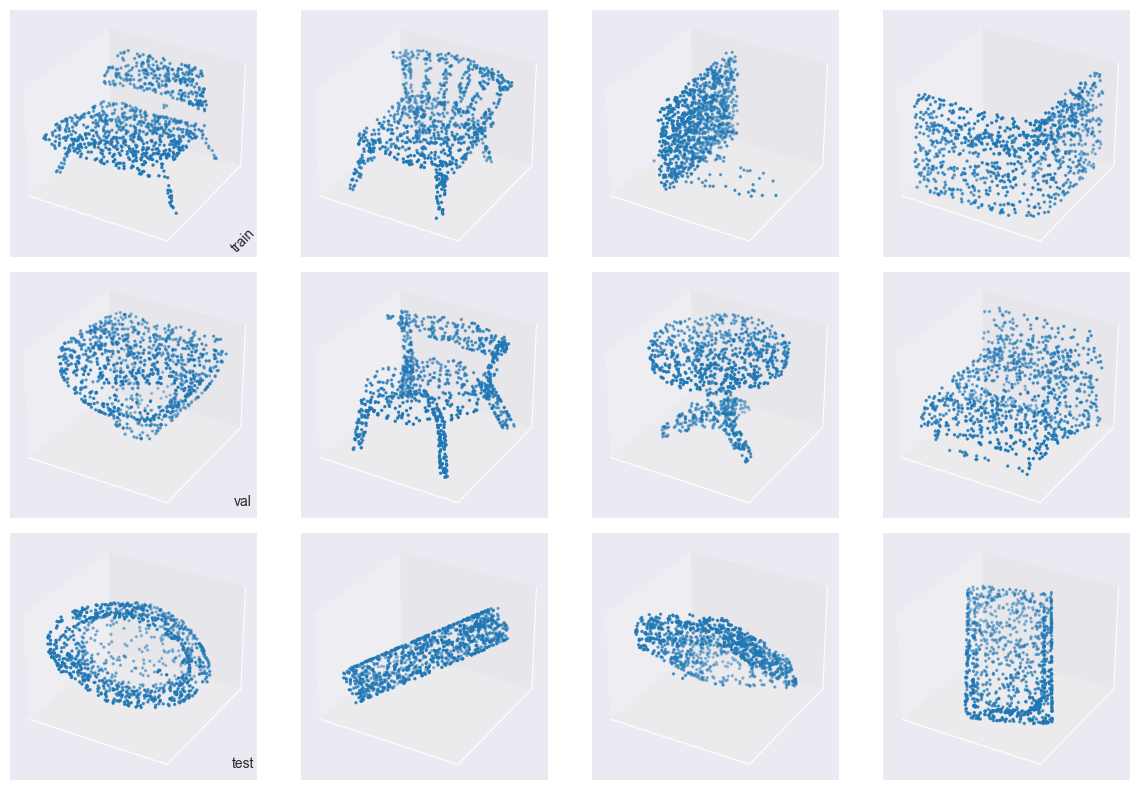

In [8]:
from utils.eval.vis import vis_dataset

vis_dataset(train_loader,val_loader,test_loader_transformed)

In [9]:
from experiment_thesis.main import train_and_get_model,train_or_load_energy_model
from experiment_thesis.dataset_preperation.basic_networks import get_network
from utils.eval.main_model import evaluate_base_model

model_dir_path = os.path.join(current_path, "experiment_files", "models")
embedding_cache_path = os.path.join(current_path, "experiment_files", "embedding_cache")
# Add results dir and helper for save paths
results_dir_path = os.path.join(current_path, "experiment_files", "results", dataset, architecture, "comparision_over_budget")
os.makedirs(results_dir_path, exist_ok=True)


def savepath(label: str) -> str:
    safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in label)
    return os.path.join(results_dir_path,transform_name, f"{safe}.json")

In [10]:
model = get_network(dataset_info,architecture, num_classes=n_classes).to(device)
modelname = f"{dataset}_{architecture}"
cache_name_train= f"{dataset}_{architecture}_embedding_cache_train"

train_and_get_model(model,model_dir_path,modelname, train_loader, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs,
        "precision": "16-mixed",
},load_if_exists=True)



Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\modelnet10_pointnetplus.safetensors
Set random_start=False for SAModule
Set random_start=False for SAModule


(TensorGeometricModelWrapper(
   (model): Sequential(
     (0): BatchNormalizeScale()
     (1): PointNetPlus(
       (sa1_module): SAModule(
         (conv): PointNetConv(local_nn=MLP(3, 64, 64, 128), global_nn=None)
       )
       (sa2_module): SAModule(
         (conv): PointNetConv(local_nn=MLP(131, 128, 128, 256), global_nn=None)
       )
       (sa3_module): GlobalSAModule(
         (nn): MLP(259, 256, 512, 1024)
       )
       (mlp): Sequential(
         (0): Linear(in_features=1024, out_features=512, bias=True)
         (1): ReLU()
         (2): Dropout(p=0.5, inplace=False)
         (3): Linear(in_features=512, out_features=256, bias=True)
         (4): ReLU()
         (5): Dropout(p=0.5, inplace=False)
         (6): Linear(in_features=256, out_features=10, bias=True)
       )
     )
   )
 ),
 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_files\\models\\modelnet10_pointnetplus.safetensors')

In [11]:
model.eval().to(device)

TensorGeometricModelWrapper(
  (model): Sequential(
    (0): BatchNormalizeScale()
    (1): PointNetPlus(
      (sa1_module): SAModule(
        (conv): PointNetConv(local_nn=MLP(3, 64, 64, 128), global_nn=None)
      )
      (sa2_module): SAModule(
        (conv): PointNetConv(local_nn=MLP(131, 128, 128, 256), global_nn=None)
      )
      (sa3_module): GlobalSAModule(
        (nn): MLP(259, 256, 512, 1024)
      )
      (mlp): Sequential(
        (0): Linear(in_features=1024, out_features=512, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.5, inplace=False)
        (3): Linear(in_features=512, out_features=256, bias=True)
        (4): ReLU()
        (5): Dropout(p=0.5, inplace=False)
        (6): Linear(in_features=256, out_features=10, bias=True)
      )
    )
  )
)

In [12]:
#res = evaluate_base_model(model, test_loader_transformed, device)
#print(res)

In [13]:
#res = evaluate_base_model(model, test_loader, device)
#print(res)

In [14]:
class TensorGeometricModelUnwrapper(torch.nn.Module):
    """
    Wrapper for a torch_geometric model that receives a tuple of (pos, y) as input and creates
    a Data object from it that is passed to the model.
    """
    def __init__(self):
        super(TensorGeometricModelUnwrapper, self).__init__()

    def forward(self, data):
        # pos and y are batched tensors from a DataLoader
        # need to reconstruct the original Data objects for torch_geometric models

        pos = data.pos
        batch = data.batch
        #split pos into individual tensors based on batch
        pos_list = torch.split(pos, torch.bincount(batch).tolist())
        return torch.stack(pos_list)

In [15]:
#chek if data is iamge data
is_image_data = len(dataset_info.input_size) == 3 and dataset_info.input_size[0] in [1, 3]

In [16]:
from utils.transforms.apply import grid_resample
from experiment_thesis.dataset_preperation.transformation import get_transformation_sequence_images

transform_seq = get_transformation_sequence_images(
                name=dataset_info.transform_seq_name,
                resample_method=dataset_info.resample_method,
    init_method="sobol"
    ).to(device)

In [17]:
from experiment_thesis.dataset_preperation.basic_networks import get_network_layer

layer,layer_io = get_network_layer(dataset_info, architecture, 0, num_classes=None, num_rotations=8)

In [18]:
from confidence.direct.logit_based import EnergyConfidence
from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence

logit_energy = SinglePassConfidence(model, EnergyConfidence(), index=None)
problem_energy_logits = TransformationProblem(logit_energy, transform_seq,                                              consolidate_method="consolidate_simple")
#test ot
from search.shgo import SHGO
random_search = SHGO(initial_samples=120, local_max_steps=0)

from utils.eval.ood_performance import load_or_run_evaluate_confidence_and_search, evaluate_confidence_and_search, \
    ITSWRAPPER


In [19]:
load_or_run_evaluate_confidence_and_search(
    model, optimizer=random_search, problem=problem_energy_logits,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("energy_confidence_transformed"), show_progress=True,
    repeats=1)

{'repeats': 1,
 'accuracy_mean': 0.2588105797767639,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.183055579662323,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.2588105797767639,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.19620442390441895,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.2588105797767639,
   'f2_macro': 0.183055579662323,
   'f2_micro': 0.2588105797767639,
   'f2_weighted': 0.19620442390441895,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None}]}

In [20]:
model.to(device).eval()

TensorGeometricModelWrapper(
  (model): Sequential(
    (0): BatchNormalizeScale()
    (1): PointNetPlus(
      (sa1_module): SAModule(
        (conv): PointNetConv(local_nn=MLP(3, 64, 64, 128), global_nn=None)
      )
      (sa2_module): SAModule(
        (conv): PointNetConv(local_nn=MLP(131, 128, 128, 256), global_nn=None)
      )
      (sa3_module): GlobalSAModule(
        (nn): MLP(259, 256, 512, 1024)
      )
      (mlp): Sequential(
        (0): Linear(in_features=1024, out_features=512, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.5, inplace=False)
        (3): Linear(in_features=512, out_features=256, bias=True)
        (4): ReLU()
        (5): Dropout(p=0.5, inplace=False)
        (6): Linear(in_features=256, out_features=10, bias=True)
      )
    )
  )
)

In [21]:
import gc
gc.collect()
torch.cuda.empty_cache()

Testing init method: individual
Axis mean vector: [-0.00763856  0.01052614  0.00773286]
Spherical variance (1 - |mean|): 0.98486906
Sample mean rotation angle (rad): 2.2203
Theoretical mean rotation angle (rad): 2.2074
KS statistic: 0.0216, p-value: 0.5796


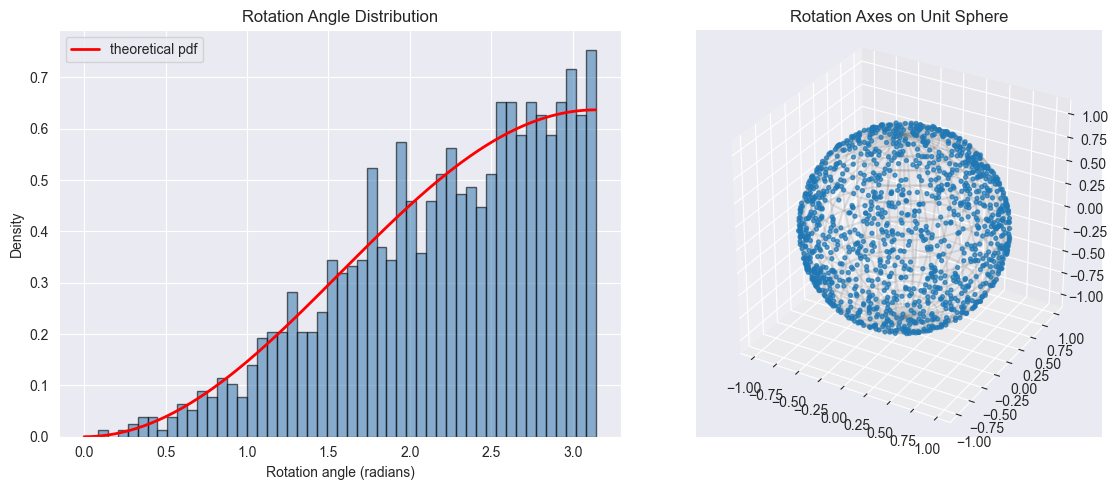

Testing init method: sobol
Axis mean vector: [-0.00295405 -0.00911528 -0.01254654]
Spherical variance (1 - |mean|): 0.98421293
Sample mean rotation angle (rad): 2.2108
Theoretical mean rotation angle (rad): 2.2074
KS statistic: 0.0142, p-value: 0.9542


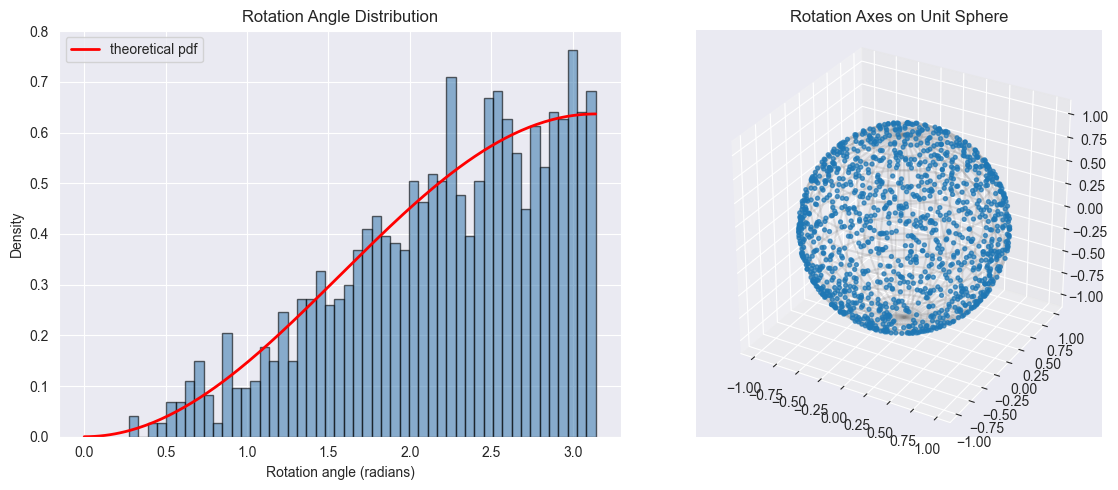

In [22]:
if "modelnet10" in dataset:
    for init_method in ["individual","sobol"]:
        print(f"Testing init method: {init_method}")
        import torch
        import kornia
        import matplotlib.pyplot as plt
        import numpy as np
        from mpl_toolkits.mplot3d import Axes3D
        from utils.affine_transforms import AffineTransformations3D
        from utils.transform_sequence import TransformSequence
        from scipy import stats

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


        # Save original init method and temporarily switch to "individual"
        original_init = transform_seq.init_method
        transform_seq.init_method = init_method

        # --- 1. Generate your matrices ---
        zw = transform_seq.initial_param(1280)
        transform_seq.init_method = original_init
        matrix = transform_seq(zw)

        # --- 2. Extract rotation submatrices ---
        R = matrix[:, :3, :3]  # [N, 3, 3]

        # --- 3. Convert to axis–angle representation ---
        rotvec = kornia.geometry.conversions.rotation_matrix_to_axis_angle(R)  # [N, 3]
        theta = torch.linalg.norm(rotvec, dim=1)
        axis = torch.nn.functional.normalize(rotvec, dim=1)

        axis_np = axis.cpu().numpy()
        theta_np = theta.cpu().numpy()

        # --- 4. Quantitative checks ---

        # (a) Axis uniformity
        mean_axis = axis_np.mean(axis=0)
        spherical_var = 1 - np.linalg.norm(mean_axis)
        print("Axis mean vector:", mean_axis)
        print("Spherical variance (1 - |mean|):", spherical_var)

        # (b) Rotation angle
        sample_mean = np.mean(theta_np)
        theory_mean = np.pi/2 + 2/np.pi  # Correct expected mean for uniform SO(3)
        print(f"Sample mean rotation angle (rad): {sample_mean:.4f}")
        print(f"Theoretical mean rotation angle (rad): {theory_mean:.4f}")

        # (c) Kolmogorov–Smirnov test against theoretical CDF
        def F_theta(t):
            # CDF for p(theta) ∝ sin²(theta/2)
            return (t - np.sin(t)) / np.pi

        ks_stat, pval = stats.kstest(theta_np, F_theta)
        print(f"KS statistic: {ks_stat:.4f}, p-value: {pval:.4f}")

        # --- 5. Visualization ---

        fig = plt.figure(figsize=(12, 5))

        # Angle histogram
        plt.subplot(1, 2, 1)
        plt.hist(theta_np, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor='black')
        t_grid = np.linspace(0, np.pi, 200)
        plt.plot(t_grid, (2/np.pi) * np.sin(t_grid/2)**2, 'r-', lw=2, label='theoretical pdf')
        plt.xlabel("Rotation angle (radians)")
        plt.ylabel("Density")
        plt.title("Rotation Angle Distribution")
        plt.legend()

        # 3D scatter of axes
        ax = fig.add_subplot(1, 2, 2, projection='3d')
        ax.scatter(axis_np[:, 0], axis_np[:, 1], axis_np[:, 2], s=8, alpha=0.7)
        # Draw reference sphere
        u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
        x = np.cos(u)*np.sin(v)
        y = np.sin(u)*np.sin(v)
        z = np.cos(v)
        ax.plot_wireframe(x, y, z, color='gray', alpha=0.2)
        ax.set_box_aspect([1,1,1])
        ax.set_title("Rotation Axes on Unit Sphere")

        plt.tight_layout()
        plt.show()


In [23]:
from utils.augments import ComposeAugmentations, random_gaussian_noise, random_contrast, \
    random_gamma  ,random_blur_or_sharpen,build_default_augmentations
import utils.augments

def dec_strat(x, idd, y_true):
    out = model(x)
    eq = out.argmax(dim=-1) == y_true
    #convert to tensor where y>=0 if correct, y<0 if incorrect
    y = torch.where(eq, y_true, -1)
    return y


from utils.augments import build_default_augmentations, small_affine_augment_2d
from utils.sampling_strategy import GaussianSamplingStrategyLatent, TransformLatentSamplingStrategy
import importlib
import utils.sampling_strategy
import utils.sampling

importlib.reload(utils.sampling)
from utils.sampling import BatchNegativeSampler


energy_model2 = get_network(dataset_info,architecture, num_classes=1).to(device)

from experiment_thesis.main import train_or_load_energy_model

if is_image_data:
    transform_true_function = small_affine_augment_2d
    affine_augment = utils.augments.build_default_augmentations()
else:
    transform_true_function = None
    affine_augment = None

negative_sampling_module = BatchNegativeSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    =transform_true_function, augment_function=affine_augment,
    decision_strategy=dec_strat,
)

energy_conf2 = train_or_load_energy_model(
    energy_model2, model_dir_path, f"{modelname}_energy2", train_loader,
    val_loader, trainer_kwargs={
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs//2,
        "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
    }, negative_sampling_module=negative_sampling_module, load_if_exists=True)


Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\modelnet10_pointnetplus_energy2_energy_conf_best.safetensors
Set random_start=False for SAModule
Set random_start=False for SAModule
Model has non-negative constraint: False


In [24]:
model.to(device).eval()

TensorGeometricModelWrapper(
  (model): Sequential(
    (0): BatchNormalizeScale()
    (1): PointNetPlus(
      (sa1_module): SAModule(
        (conv): PointNetConv(local_nn=MLP(3, 64, 64, 128), global_nn=None)
      )
      (sa2_module): SAModule(
        (conv): PointNetConv(local_nn=MLP(131, 128, 128, 256), global_nn=None)
      )
      (sa3_module): GlobalSAModule(
        (nn): MLP(259, 256, 512, 1024)
      )
      (mlp): Sequential(
        (0): Linear(in_features=1024, out_features=512, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.5, inplace=False)
        (3): Linear(in_features=512, out_features=256, bias=True)
        (4): ReLU()
        (5): Dropout(p=0.5, inplace=False)
        (6): Linear(in_features=256, out_features=10, bias=True)
      )
    )
  )
)

In [25]:
from experiment_thesis.dataset_preperation.basic_networks import make_deterministic

make_deterministic(model)
make_deterministic(energy_model2)

Set random_start=False for SAModule
Set random_start=False for SAModule
Set random_start=False for SAModule
Set random_start=False for SAModule


In [26]:
energy_conf2.to(device).eval()



problem_energy2 = TransformationProblem(energy_conf2, transform_seq,                                              consolidate_method="consolidate_simple")



In [27]:
load_or_run_evaluate_confidence_and_search(
    model, optimizer=random_search, problem=problem_energy2,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("learned_energy_confidence_transformed"), show_progress=True,
    repeats=1)

{'repeats': 1,
 'accuracy_mean': 0.5892070531845093,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.5654647946357727,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.5892070531845093,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.5773270726203918,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.5892070531845093,
   'f2_macro': 0.5654647946357727,
   'f2_micro': 0.5892070531845093,
   'f2_weighted': 0.5773270726203918,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None}]}

In [28]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [29]:
from torch.utils.data import SequentialSampler
from embedding_cache import LayerEmbeddingCache



cache_name_train = f"{dataset}_{architecture}_{transform_name}_embedding_cache_train"

cache_train = LayerEmbeddingCache(model, train_loader_no_shuffle,
                                  cache_dir=os.path.join(embedding_cache_path, cache_name_train))

dual_output_model = cache_train.make_wrapper(layer, capture_modes=layer_io, concat=False, flatten=True)
embeddings_t, final_t, classes_t = cache_train.__call__(layer, capture_modes=layer_io, flatten=True)




from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence, PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence, PerClassKNNConfidence

from confidence.input_transform import InputTransformImage, PCAInputModule, RandomProjectionModule

nn_pytorch_pretrained = PerClassKNNConfidence(metric="cosine", input_transform=None,computation_mode="masked",k=1)
nn_pytorch_pretrained.fit(embeddings_t, classes_t)
nn_pytorch_pretrained.to(device)

conf_split_pretrained = PredictedSplitConfidence(nn_pytorch_pretrained, EnergyConfidence(), mult=False, b=0.0)
conf_mod_nn_pytorch_pretrained = SinglePassConfidence(dual_output_model, conf_split_pretrained, index=1)
problem_nn_pytorch_pretrained = TransformationProblem(conf_mod_nn_pytorch_pretrained, transform_seq,
                                                      consolidate_method="consolidate_simple")
model.eval().to(device)

TensorGeometricModelWrapper(
  (model): Sequential(
    (0): BatchNormalizeScale()
    (1): PointNetPlus(
      (sa1_module): SAModule(
        (conv): PointNetConv(local_nn=MLP(3, 64, 64, 128), global_nn=None)
      )
      (sa2_module): SAModule(
        (conv): PointNetConv(local_nn=MLP(131, 128, 128, 256), global_nn=None)
      )
      (sa3_module): GlobalSAModule(
        (nn): MLP(259, 256, 512, 1024)
      )
      (mlp): Sequential(
        (0): Linear(in_features=1024, out_features=512, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.5, inplace=False)
        (3): Linear(in_features=512, out_features=256, bias=True)
        (4): ReLU()
        (5): Dropout(p=0.5, inplace=False)
        (6): Linear(in_features=256, out_features=10, bias=True)
      )
    )
  )
)

In [30]:
#benchmark model and dual output model

In [31]:
load_or_run_evaluate_confidence_and_search(
    model, optimizer=random_search, problem=problem_nn_pytorch_pretrained,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("knn_per_class_confidence_transformed"), show_progress=True,
    repeats=1,overwrite=False)

{'repeats': 1,
 'accuracy_mean': 0.4592511057853699,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.41348201036453247,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.4592511057853699,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.4248042106628418,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.4592511057853699,
   'f2_macro': 0.41348201036453247,
   'f2_micro': 0.4592511057853699,
   'f2_weighted': 0.4248042106628418,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None}]}

In [32]:
gc.collect()
torch.cuda.empty_cache()

In [33]:
x = next(iter(train_loader_no_shuffle))

res1= dual_output_model(x[0].to(device))[0].cpu().detach().numpy()

res2 = embeddings_t[:x[0].shape[0]].cpu().detach().numpy()
if not np.allclose(res1, res2,rtol=1e-5, atol=1e-5):
    raise ValueError("Model is not deterministic!")
else:
    print("Model is deterministic.")

del res1
del res2
del x

Model is deterministic.


In [34]:
from utils.eval.ood_performance import ITSWRAPPER
import importlib
import its.search
importlib.reload(its.search)

its2 = ITSWRAPPER(its.search.InverseTransformationSearch(model,None,None,n_hypotheses=1,n_samples=10,extend=0,gaussian_filter_channel_wise=True))

In [35]:
from search.tree import CoordinateDescent
cd = CoordinateDescent()

In [36]:
gc.collect(

)
torch.cuda.empty_cache()

In [37]:
gc.collect()
torch.cuda.empty_cache()

In [38]:
x = next(iter(test_loader_transformed))[0].to(device)

In [39]:
from utils.affine_transforms import AffineTransformations3D,AffineTransformation2D
from utils.transform_sequence import TransformSequence
from utils.transformation_problem import TransformationProblem



In [40]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [41]:
from utils.replacer import replace_rotation_transforms, replace_rotation_transforms_2vec
import os
import optuna
import torch
import gc
import numpy as np
from torch.utils.data import Subset, DataLoader

from search.objective_generators import (
    make_search_objective,
    save_best_trial_params,
    build_search_algorithm,
    _cost_shgo,  # cost helper for sanity checks
)
from search.config import load_params, get_default_params, save_params
from utils.eval.ood_performance import load_or_run_evaluate_confidence_and_search

model.eval().to(device)
# detach model for efficent gradients
for param in model.parameters():
    param.requires_grad = False

for param in energy_model2.parameters():
    param.requires_grad = False

# Algorithms and budgets
all_algos = ["shgo", "wcd_lattice", "its", "random_search"]
# "cmaes" #cmaes seems currently alway to default to only using 0 iterations.
# add "its" if you have an ITS optimizer/module wired up

#for bigger mnist and bigger emnist add shgo
#if dataset in ["bigger_mnist","bigger_emnist","coil100"]:
 #   all_algos.append("shgo")


# remove pgd pgd restarts and pgd window size for tu berlin
if dataset in ["tu_berlin"]:
    all_algos = ["wcd_lattice", "its", "random_search"]
    grad_weight = 99999999
elif dataset in ["modelnet10"]:
    all_algos = ["shgo_vector", "wcd_lat_ind", "random_search", "its","shgo","shgo_c"]
    grad_weight = 2
else:
    grad_weight = 2

# Add complex/quaternion variants
complex_algos = ["shgo_c", "pgd_c", "shgo_c_3"]


budgets = [8, 15,30, 60, 120, 240]

grad_weight_algos = {"shgo", "shgo_individual", "pgd", "pgd_restart", "pgd_window",
                     "shgo_c", "pgd_c", "pgd_restart_c", "shgo_c_3", "pgd_c_3", "pgd_vector", "shgo_vector"}
default_trials = 30
eval_repeats = 5
if dataset == "modelnet10" or dataset == "tu_berlin" or dataset =="coil100":
    eval_repeats = 10
show_progress = True

# Problem configurations
problems = [problem_energy_logits, problem_nn_pytorch_pretrained, problem_energy2]
problem_names = ["logit_energy", "knn_per_class", "learned_energy"]

# Create complex/quaternion versions of problems
problems_complex = [replace_rotation_transforms(p) for p in problems]
problem_names_complex = problem_names

# New problems for shgo_individual
problems_individual = [ITSWRAPPER._prepare_problem(p) for p in problems]
problem_names_individual = problem_names

problems_rotvec = [replace_rotation_transforms_2vec(p) for p in problems]
problem_names_rotvec = problem_names

for p in problems:
    p.max_batch_size = dataset_info.batch_size_search
for p in problems_individual:
    p.max_batch_size = dataset_info.batch_size_search
for p in problems_complex:
    p.max_batch_size = dataset_info.batch_size_search

# Base results directory
base_results_dir = os.path.join(
    current_path, "experiment_files", "search_results_compare_budget",
    str(dataset), dataset_info.transform_seq_name, str(architecture)
)
os.makedirs(base_results_dir, exist_ok=True)

assert len(problems) == len(problem_names), "Mismatch between problems and problem_names."

# Mapping from complex variants to their base algorithms
algo_variant_mapping = {
    "pgd_c": "pgd",
    "shgo_c": "shgo",
    "pgd_restart_c": "pgd_restart",
    "shgo_c_3": "shgo",  # NEW: map to base shgo
    "pgd_c_3": "pgd",  # NEW: map to base pgd
    "pgd_vector": "pgd",
    "shgo_vector": "shgo",
}

# Create subsampled validation loaders (before budget loop)
val_dataset_original = val_loader_transformed.dataset
n_val = len(val_dataset_original)
rng_seed = 42
rng = np.random.default_rng(rng_seed)
perm = rng.permutation(n_val)

half_n = n_val // 2
quarter_n = n_val // 4

indices_half = perm[:half_n]
indices_quarter = perm[:quarter_n]

# Create half-size validation loader
val_loader_transformed_half = DataLoader(
    Subset(val_dataset_original, indices_half),
    batch_size=max(dataset_info.batch_size//2, 1),
    shuffle=False,
    num_workers=val_loader_transformed.num_workers,
    pin_memory=True,
    persistent_workers=getattr(val_loader_transformed, "persistent_workers", False),
)

# Create quarter-size validation loader
val_loader_transformed_quarter = DataLoader(
    Subset(val_dataset_original, indices_quarter),
    batch_size=max(dataset_info.batch_size//4, 1),
    shuffle=False,
    num_workers=val_loader_transformed.num_workers,
    pin_memory=True,
    persistent_workers=getattr(val_loader_transformed, "persistent_workers", False),
)

test_loader_lower_batch_size =DataLoader(
    test_loader_transformed.dataset,
    batch_size=max(dataset_info.batch_size//2, 1),
    shuffle=False,
    num_workers=test_loader_transformed.num_workers,
    pin_memory=True,
    persistent_workers=getattr(test_loader_transformed, "persistent_workers", False),
)

grad_weight_orig = grad_weight
for budget in budgets:
    print(f"\n=== Budget: {budget} ===")
    for algo in all_algos:
            # Determine validation loader and eval repeats based on budget
        if budget > 200:
            val_dataset_transformed_loader = val_loader_transformed_quarter
            repeats_for_eval = eval_repeats//2
        elif budget > 100:
            val_dataset_transformed_loader = val_loader_transformed_half
            repeats_for_eval = (eval_repeats*3)//4
        else:
            val_dataset_transformed_loader = val_loader_transformed
            repeats_for_eval = eval_repeats
        if "its" in algo:
            repeats_for_eval = 1



        gc.collect()
        torch.cuda.empty_cache()
        print(f"\n--- Algorithm: {algo} ---")

        # NEW: special grad_weight override
        if algo == "shgo_c_3" or algo == "pgd_c_3":
            grad_weight = 3
        else:
            grad_weight = grad_weight_orig

        # Determine which problems to use
        if algo in complex_algos:
            current_problems = problems_complex
            current_problem_names = problem_names_complex
        elif algo in ["shgo_individual", "wcd_lat_ind"]:
            current_problems = problems_individual
            current_problem_names = problem_names_individual
        elif algo in ["pgd_vector", "shgo_vector"]:
            current_problems = problems_rotvec
            current_problem_names = problem_names_rotvec
        else:
            current_problems = problems
            current_problem_names = problem_names

        for p in current_problems:
            p.max_batch_size = dataset_info.batch_size_search

        # Map algorithm names for construction
        if algo in complex_algos:
            algo_name_for_path = algo_variant_mapping[algo]
        elif algo == "shgo_individual":
            algo_name_for_path = "shgo"
        elif algo == "wcd_lat_ind":
            algo_name_for_path = "wcd_lattice"
        elif algo in ["pgd_vector", "shgo_vector"]:
            algo_name_for_path = algo_variant_mapping[algo]
        else:
            algo_name_for_path = algo

        algo_dir = os.path.join(base_results_dir, algo, f"budget_{budget}")
        os.makedirs(algo_dir, exist_ok=True)

        param_path = os.path.join(algo_dir, "best.yml")
        print(f"Result directory: {algo_dir}")

        # Load stored params or optimize
        stored_params = load_params(param_path) if os.path.exists(param_path) else None
        if stored_params is None and (algo != "cd" and "random_search" not in algo):
            default_params_kwargs = {}
            if algo in grad_weight_algos:
                default_params_kwargs["grad_weight"] = grad_weight
            default_params = get_default_params(algo_name_for_path, budget, **default_params_kwargs)
            print("Default params (config):", default_params)

            objective_kwargs = {}
            if algo in grad_weight_algos:
                objective_kwargs["grad_weight"] = grad_weight

            objective = make_search_objective(
                algo=algo_name_for_path,
                model=model,
                val_loader=val_dataset_transformed_loader,  # Use budget-dependent validation loader
                problem=current_problems,  # multi-problem objective
                budget=budget,
                device=str(device),
                repeats=1,
                **objective_kwargs,
            )

            pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0, interval_steps=1)
            study = optuna.create_study(direction="maximize", pruner=pruner)
            study.enqueue_trial(default_params)

            study.optimize(objective, n_trials=default_trials, show_progress_bar=False)

            print(f"[{algo}] Best validation value:", study.best_value)
            print("Suggested params:", study.best_trial.params)
            print("Full params:", study.best_trial.user_attrs.get("full_params"))

            save_best_trial_params(study, algo=algo_name_for_path, path=param_path)
            stored_params = load_params(param_path)
            print("Saved best params to:", param_path)
        else:
            print("Found stored best params, skipping optimization.")
            if "cd" == algo:
                print("Note: 'cd' algorithm requires no hyperparameter optimization.")
                stored_params = {}

        # SHGO-only sanity check: force full budget consumption by topping up n_init
        if algo in ["shgo", "shgo_individual", "shgo_c", "shgo_c_3"]:  # NEW: added shgo_c_3
            gw = stored_params.get("grad_weight", 2)
            cost = _cost_shgo(
                stored_params["shgo_initial_samples"],
                stored_params["shgo_local_runs"],
                stored_params["shgo_local_steps"],
                gw,
            )
            if cost != budget:
                delta = budget - cost
                # Adjust n_init up/down to match budget exactly
                stored_params["shgo_initial_samples"] = max(
                    1,
                    stored_params["shgo_initial_samples"] + delta
                )
                # Recompute and assert
                new_cost = _cost_shgo(
                    stored_params["shgo_initial_samples"],
                    stored_params["shgo_local_runs"],
                    stored_params["shgo_local_steps"],
                    gw,
                )
                print(f"[{algo}] adjusted n_init by {delta} to match budget: {cost} -> {new_cost}")
                assert new_cost == budget, f"SHGO cost mismatch after fix: {new_cost}!={budget}"
                # Persist the fix
                save_params(stored_params, param_path)

        # assert that grad weight matches
        if algo in grad_weight_algos:
            assert stored_params.get("grad_weight", None) == grad_weight, \
                f"Grad weight mismatch for {algo}: {stored_params.get('grad_weight', None)}!={grad_weight}"

        # Rebuild optimizer with best params
        search_obj = build_search_algorithm(
            algo_name_for_path,
            stored_params,
            problem=current_problems[0],  # any problem is fine for optimizer construction
            budget=budget,
            model=model,
        )
        print("Rebuilt search object from saved params.")

        # Evaluate per problem with cached runner
        for prob, method_name in zip(current_problems, current_problem_names):
            eval_path = os.path.join(algo_dir, f"eval_{method_name}.json")
            print(f"[{method_name}] evaluating (cached path: {eval_path})")
            metrics = load_or_run_evaluate_confidence_and_search(
                model=model,
                optimizer=search_obj,
                problem=prob,
                test_loader=test_loader_transformed if budget< 200 else test_loader_lower_batch_size,
                save_path=eval_path,  # auto-loads if exists; saves after run otherwise
                max_batch_override=dataset_info.batch_size_search,
                show_progress=show_progress,
                repeats=repeats_for_eval,  # Use budget-dependent repeats
                return_per_run=True,
                overwrite=False, store_val=True
            )
            gc.collect()
            torch.cuda.empty_cache()


=== Budget: 8 ===

--- Algorithm: shgo_vector ---
Result directory: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\search_results_compare_budget\modelnet10\modelnet_default\pointnetplus\shgo_vector\budget_8
Found stored best params, skipping optimization.
Rebuilt search object from saved params.
[logit_energy] evaluating (cached path: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\search_results_compare_budget\modelnet10\modelnet_default\pointnetplus\shgo_vector\budget_8\eval_logit_energy.json)

[knn_per_class] evaluating (cached path: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\search_results_compare_budget\modelnet10\modelnet_default\pointnetplus\shgo_vector\budget_8\eval_knn_per_class.json)

[learned_energy] evaluating (cached path: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\search_results_compare_budget\modelnet10\modelnet_default\pointnetplus\shgo_vector\budget_8\eval_learned_en

In [42]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [43]:
import pandas as pd
import json
import os
import matplotlib.pyplot as plt

# Collect results
results = []

for budget in budgets:
    for algo in all_algos:
        algo_dir = os.path.join(base_results_dir, algo, f"budget_{budget}")
        for method_name in problem_names:
            eval_path = os.path.join(algo_dir, f"eval_{method_name}.json")
            if os.path.exists(eval_path):
                with open(eval_path, "r") as f:
                    metrics = json.load(f)
                accuracy = metrics.get("accuracy_mean", None)
                accuracy_se= metrics.get("accuracy_se", None)
                results.append({
                    "Algorithm": algo,
                    "Budget": budget,
                    "Problem": method_name,
                    "Accuracy": accuracy,
                    "Accuracy_SE": accuracy_se,

                })

# Convert to DataFrame
df = pd.DataFrame(results)




In [44]:
df

,Algorithm,Budget,Problem,Accuracy,Accuracy_SE
0,shgo_vector,8,logit_energy,0.260573,0.002258
1,shgo_vector,8,knn_per_class,0.287225,0.003008
2,shgo_vector,8,learned_energy,0.395264,0.003215
3,wcd_lat_ind,8,logit_energy,0.266850,0.003978
4,wcd_lat_ind,8,knn_per_class,0.319493,0.003684
...,...,...,...,...,...
103,shgo,240,knn_per_class,0.531718,0.006302
104,shgo,240,learned_energy,0.607269,0.004330
105,shgo_c,240,logit_energy,0.249339,0.001958
106,shgo_c,240,knn_per_class,0.537445,0.006948


In [45]:
transform_seq.transformations

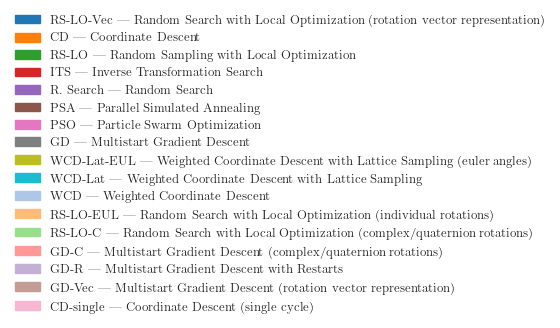

In [46]:

import pandas as pd
import json
import os
import matplotlib.pyplot as plt

# Collect results
results = []

for budget in budgets:
    for algo in all_algos:
        algo_dir = os.path.join(base_results_dir, algo, f"budget_{budget}")
        for method_name in problem_names:
            eval_path = os.path.join(algo_dir, f"eval_{method_name}.json")
            if os.path.exists(eval_path):
                with open(eval_path, "r") as f:
                    metrics = json.load(f)

                accuracy = metrics.get("accuracy_mean", None)
                accuracy_se = metrics.get("accuracy_se", None)
                accuracy_std = metrics.get("accuracy_std", None)
                number_of_runs = metrics.get("repeats", None)
                results.append({
                    "Algorithm": algo,
                    "Budget": budget,
                    "Problem": method_name,
                    "Accuracy": accuracy,
                    "Accuracy_SE": accuracy_se,
                    "Accuracy_STD": accuracy_std,
                    "Number_of_Runs": number_of_runs,

                })

# Convert to DataFrame
df = pd.DataFrame(results)

df
transform_seq.transformations
ALGO_RENAME = {
    "cd": "CD-single",
    "cd_multi_cyclus": "CD",
    "shgo": "RS-LO",
    "parallel_sa": "PSA",
    "pso": "PSO",
    "pgd": "GD",
    "pgd_restart": "GD-R",
    "its": "ITS",
    "random_search": "R. Search",
    "wcd": "WCD",
    "wcd_lattice": "WCD-Lat",
    "shgo_c": "RS-LO-C",
    "pgd_c": "GD-C",
    "wcd_lat_ind": "WCD-Lat-EUL",
    "pgd_vector": "GD-Vec",
    "shgo_vector": "RS-LO-Vec",
}

PROBLEM_RENAME = {
    "knn_per_class": "PC-kNN",
    "logit_energy": "Logit-Energy",
    "learned_energy": "Learned-Energy",
}

#do some renaming

df_renamed = df.copy()
#rename cd to cd_signle_cycle
#rename cd_multi_cyclus to cd
#rename shgo to RS-LO
df_renamed["Algorithm"] = df["Algorithm"].replace(ALGO_RENAME)

#reanme problem name from knn_per_class to PC-kNN
df_renamed["Problem"] = df["Problem"].replace(PROBLEM_RENAME)
problem_names_renamed = ["Logit-Energy", "PC-kNN", "Learned-Energy"]

fullname_dict = {
    "RS-LO-Vec": "Random Search with Local Optimization (rotation vector representation)",
    "CD": "Coordinate Descent",
    "RS-LO": "Random Sampling with Local Optimization",
    "ITS": "Inverse Transformation Search",
    "R. Search": "Random Search",
    "PSA": "Parallel Simulated Annealing",
    "PSO": "Particle Swarm Optimization",
    "GD": "Multistart Gradient Descent",
    "WCD-Lat-EUL": "Weighted Coordinate Descent with Lattice Sampling (euler angles)",
    "WCD-Lat": "Weighted Coordinate Descent with Lattice Sampling",
    "WCD": "Weighted Coordinate Descent",
    "RS-LO-EUL": "Random Search with Local Optimization (individual rotations)",
    "RS-LO-C": "Random Search with Local Optimization (complex/quaternion rotations)",
    "GD-C": "Multistart Gradient Descent (complex/quaternion rotations)",
    "GD-R": "Multistart Gradient Descent with Restarts",
    "GD-Vec": "Multistart Gradient Descent (rotation vector representation)",
    "CD-single": "Coordinate Descent (single cycle)",
}


import matplotlib.pyplot as plt

short_names = list(fullname_dict.keys())
n = len(short_names)

# Get all 20 colors from tab20
tab20_colors = [plt.get_cmap("tab20")(i)[:3] for i in range(20)]

# Separate even and odd indices
even_colors = tab20_colors[::2]  # 0, 2, 4, ..., 18
odd_colors = tab20_colors[1::2]  # 1, 3, 5, ..., 19

# Combine: even first, then odd
ordered_colors = even_colors + odd_colors

# Repeat pattern if more names than 20
if n > 20:
    repeats = (n // 20) + 1
    ordered_colors = (ordered_colors * repeats)[:n]
else:
    ordered_colors = ordered_colors[:n]

# Assign to names
algorithm_colors = {name: ordered_colors[i] for i, name in enumerate(short_names)}

figure_path = os.path.join(current_path, "experiment_files", "export", "fig", "comparision_search_datasets", dataset,
                           transform_name)
if not os.path.exists(figure_path):
    os.makedirs(figure_path)
from matplotlib.patches import Patch
from utils.eval.vis import plt_setup_latex

W = plt_setup_latex()
handles = [
    Patch(color=algorithm_colors[short], label=f"{short} — {fullname_dict[short]}")
    for short in fullname_dict
]

# Plot legend in a separate figure
fig, ax = plt.subplots(figsize=(W, W * 0.4))
ax.legend(
    handles=handles,
    loc='center',
    frameon=False,
    fontsize=9
)
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(figure_path, "comparision_search_algorithms_legend.pdf"))
plt.savefig(os.path.join(figure_path, "comparision_search_algorithms_legend.pgf"))
plt.show()

In [47]:

figure_path = os.path.join(current_path,"experiment_files","export","fig","comparision_search_budget",dataset,transform_name)
if not os.path.exists(figure_path):
    os.makedirs(figure_path)

Saved figure to:
  C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\export\fig\comparision_search_budget\modelnet10\modelnet_default\accuracy_vs_budget_side_by_side.pdf
  C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\export\fig\comparision_search_budget\modelnet10\modelnet_default\accuracy_vs_budget_side_by_side.pgf


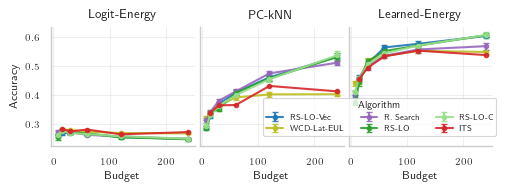

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

def plot_accuracy_vs_budget_side_by_side(
    df,
    problem_names,
    algo_column="Algorithm",
    problem_column="Problem",
    x_column="Budget",
    y_column="Accuracy",
    se_column="Accuracy_SE",
    algorithm_colors=None,
    fig_width=10,
    fig_height=None,
    figure_path=None,
    save_name="accuracy_vs_budget_side_by_side"
):
    """
    Plots Accuracy vs Budget curves for each problem side-by-side with error bars,
    and optionally saves the figure as both PDF and PGF.

    Parameters:
        df : pd.DataFrame
            DataFrame containing results.
        problem_names : list
            List of problem names to plot (order matters).
        algo_column : str
            Column name for algorithm labels.
        problem_column : str
            Column name for problem names.
        x_column : str
            Column for x-axis values (e.g. "Budget").
        y_column : str
            Column for y-axis values (e.g. "Accuracy").
        se_column : str
            Column for standard errors.
        algorithm_colors : dict
            Optional mapping {algorithm: color}.
        fig_width, fig_height : float
            Dimensions of the overall figure.
        figure_path : str
            Path to directory for saving the figure.
        save_name : str
            Base name for output file (without extension).
    """
    #remove its with budget 8
    df = df[~((df[algo_column]=="ITS") & (df[x_column]==8))]
    sns.set(style="whitegrid", context="paper")

    n_problems = len(problem_names)
    if fig_height is None:
        fig_height = fig_width * 0.4

    fig, axes = plt.subplots(
        1, n_problems,
        figsize=(fig_width, fig_height),
        sharey=True
    )

    if n_problems == 1:
        axes = [axes]

    for ax, problem in zip(axes, problem_names):
        problem_df = df[df[problem_column] == problem]

        for algorithm in problem_df[algo_column].unique():
            alg_df = problem_df[problem_df[algo_column] == algorithm]

            color = None
            if algorithm_colors and algorithm in algorithm_colors:
                color = algorithm_colors[algorithm]

            ax.errorbar(
                alg_df[x_column],
                alg_df[y_column],
                yerr=alg_df[se_column]*1.96,
                marker="o",
                label=algorithm,
                capsize=2,
                linewidth=1.5,
                markersize=3,
                color=color,
                alpha=0.9
            )

        ax.set_title(problem, fontsize=9)
        ax.set_xlabel("Budget", fontsize=8)
        if ax == axes[0]:
            ax.set_ylabel("Accuracy", fontsize=8)
        else:
            ax.set_ylabel("")
        ax.tick_params(axis='both', labelsize=7)
        ax.grid(True, alpha=0.3)
        sns.despine(ax=ax)

    # Shared legend at top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels, title="Algorithm",
        loc="lower right", ncol=len(labels)//2,
        bbox_to_anchor=(1.0, 0.25),
        fontsize=6, title_fontsize=7
    )

    plt.tight_layout(pad=0.6, w_pad=0.3)
    plt.subplots_adjust(top=0.82)  # leave room for legend

    # Save as PDF and PGF if path provided
    if figure_path is not None:
        os.makedirs(figure_path, exist_ok=True)
        pdf_path = os.path.join(figure_path, f"{save_name}.pdf")
        pgf_path = os.path.join(figure_path, f"{save_name}.pgf")
        plt.savefig(pdf_path, bbox_inches="tight")
        plt.savefig(pgf_path, bbox_inches="tight")
        print(f"Saved figure to:\n  {pdf_path}\n  {pgf_path}")

    plt.show()


# Example usage
plot_accuracy_vs_budget_side_by_side(
    df=df_renamed,
    problem_names=problem_names_renamed,
    algorithm_colors=algorithm_colors,
    fig_width=W,
    figure_path=figure_path
)


C:\Users\Lindner\AppData\Local\Temp\ipykernel_47980\3139060084.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_combined_se)


Saved figure to:
  C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\export\fig\comparision_search_budget\modelnet10\modelnet_default\accuracy_vs_budget_overall.pdf
  C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\export\fig\comparision_search_budget\modelnet10\modelnet_default\accuracy_vs_budget_overall.pgf


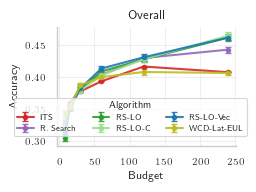

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set(style="whitegrid", context="talk")


# --- Step 1: Compute mean and combined SE (propagating within-problem uncertainty) ---
def compute_combined_se(group):
    """
    Compute combined mean and SE across problems, properly propagating uncertainty.
    """
    N = len(group)  # number of problems

    # Mean across problems
    mean_accuracy = group["Accuracy"].mean()

    # Variance of each problem mean: s_i^2 / n_i
    var_each = (group["Accuracy_STD"].to_numpy() ** 2) / group["Number_of_Runs"].to_numpy()

    # Combined SE across problems (propagating uncertainty)
    se_combined = np.sqrt(np.sum(var_each)) / N

    return pd.Series({
        "Accuracy_mean": mean_accuracy,
        "Accuracy_SE": se_combined
    })

summary_df = (
    df_renamed
    .groupby(["Algorithm", "Budget"], as_index=False)
    .apply(compute_combined_se)
    .reset_index(drop=True)
)
summary_df["Problem"] = "Overall"  # placeholder for consistency

plot_accuracy_vs_budget_side_by_side(
    df=summary_df,
    problem_names=["Overall"],   # matches the column value
    algo_column="Algorithm",
    problem_column="Problem",    # <- pass the actual column name
    x_column="Budget",
    y_column="Accuracy_mean",
    se_column="Accuracy_SE",
    algorithm_colors=algorithm_colors,
    fig_width=W/2,
    fig_height=W * 0.4,
    figure_path=figure_path,
    save_name="accuracy_vs_budget_overall"
)


In [50]:
#load its best hyperparameter per budget and print the number of hypothesis. Similarly for wcd_lattice print the number of rounds
import os
import yaml
for budget in budgets:
    for algo in ["shgo_c"]:
        algo_dir = os.path.join(base_results_dir, algo, f"budget_{budget}")
        param_path = os.path.join(algo_dir, "best.yml")
        if os.path.exists(param_path):
            with open(param_path, "r") as f:
                params = yaml.safe_load(f)
            if algo == "shgo_c":
                n_rounds = params.get("n_rounds", None)
                print(f"[Budget {budget}] WCD Lattice n_rounds: {n_rounds}")
                print(params)

[Budget 8] WCD Lattice n_rounds: None
{'grad_weight': 2, 'shgo_acceptance_criterion': 'step', 'shgo_initial_samples': 5, 'shgo_local_opt': 'adam', 'shgo_local_runs': 1, 'shgo_local_steps': 1, 'shgo_lr': 0.16874645463900953, 'shgo_selection_method': 'knn'}
[Budget 15] WCD Lattice n_rounds: None
{'grad_weight': 2, 'shgo_acceptance_criterion': 'final', 'shgo_initial_samples': 12, 'shgo_local_opt': 'adam', 'shgo_local_runs': 1, 'shgo_local_steps': 1, 'shgo_lr': 0.20611166547278995, 'shgo_selection_method': 'topk'}
[Budget 30] WCD Lattice n_rounds: None
{'grad_weight': 2, 'shgo_acceptance_criterion': 'step', 'shgo_initial_samples': 23, 'shgo_local_opt': 'adam', 'shgo_local_runs': 1, 'shgo_local_steps': 3, 'shgo_lr': 0.008599865561506615, 'shgo_selection_method': 'knn'}
[Budget 60] WCD Lattice n_rounds: None
{'grad_weight': 2, 'shgo_acceptance_criterion': 'always', 'shgo_initial_samples': 45, 'shgo_local_opt': 'adam', 'shgo_local_runs': 1, 'shgo_local_steps': 7, 'shgo_lr': 0.0135622431456809

In [51]:
def analyze_run_results_with_budget(results_list):
    """
    Computes summary statistics per algorithm and budget for each problem.
    Uses global min-max normalization across all budgets, runs, and algorithms.
    Frobenius distance is computed against the global best run per sample.
    """
    import numpy as np
    from collections import defaultdict

    # Apply renaming first, then group
    for entry in results_list:
        algo = ALGO_RENAME.get(entry["Algorithm"], entry["Algorithm"])
        problem_name = PROBLEM_RENAME.get(entry["Problem"], entry["Problem"])
        entry["Algorithm"] = algo
        entry["Problem"] = problem_name

    results_by_problem = defaultdict(list)
    for entry in results_list:
        results_by_problem[entry["Problem"]].append(entry)

    problem_summaries = {}

    for problem, entries in results_by_problem.items():
        # First pass: collect all errors globally to find min/max and best run per sample
        all_errors_global = []
        all_mats_global = []
        metadata_global = []
        all_true_labels, all_pred_labels = [], []

        for entry in entries:
            algo = entry["Algorithm"]
            problem_name = entry["Problem"]
            budget = entry["Budget"]

            res = entry["metrics"]
            runs = res.get("per_run", [res])

            for run_idx, run in enumerate(runs):
                if "per_sample_errors" not in run or "per_sample_matrices" not in run:
                    continue

                errs = np.array(run["per_sample_errors"], dtype=float)
                mats = run["per_sample_matrices"]

                all_errors_global.append(errs)
                all_mats_global.append(mats)
                metadata_global.append({
                    'algo': algo,
                    'budget': budget,
                    'run_idx': run_idx
                })

                if "per_sample_true_labels" in run:
                    all_true_labels.append(run["per_sample_true_labels"])
                if "per_sample_pred_labels" in run:
                    all_pred_labels.append(run["per_sample_pred_labels"])

        if not all_errors_global:
            continue

        array_labels = np.array(all_true_labels)
        assert np.all(array_labels == array_labels[0]), "Rows are not equal"

        all_errors_global = np.stack(all_errors_global)
        eps = 1e-12
        num_samples = all_errors_global.shape[1]

        # Global min/max across all budgets and algorithms
        min_errors = np.nanmin(all_errors_global, axis=0)
        max_errors = np.nanmax(all_errors_global, axis=0)
        denom = max_errors - min_errors + eps

        # Global best run per sample
        best_run_idx_per_sample = np.nanargmin(
            np.where(np.isnan(all_errors_global), np.inf, all_errors_global), axis=0
        )
        best_mats = [all_mats_global[idx][j] for j, idx in enumerate(best_run_idx_per_sample)]

        # Best predicted labels
        best_pred_labels = None
        pred_labels_available = len(all_pred_labels) == len(all_errors_global)
        if pred_labels_available:
            best_pred_labels = [
                all_pred_labels[idx][j] for j, idx in enumerate(best_run_idx_per_sample)
            ]

        # Vectorized relative error computation
        relative_errors_global = (all_errors_global - min_errors[None, :]) / denom[None, :]

        # Pre-compute Frobenius distances

        best_mats_array = np.array(best_mats, dtype=float)
        all_mats_stacked = []
        for run_mats in all_mats_global:
            run_mats_array = np.array(run_mats[:num_samples], dtype=float)
            all_mats_stacked.append(run_mats_array)
        all_mats_stacked = np.array(all_mats_stacked)

        diff = all_mats_stacked - best_mats_array[None, :, ...]
        shape = diff.shape
        diff_flat = diff.reshape(shape[0], shape[1], -1)
        best_flat = best_mats_array.reshape(shape[1], -1)

        diff_norms = np.linalg.norm(diff_flat, axis=2)
        best_norms = np.linalg.norm(best_flat, axis=1)

        frobenius_distances_global = diff_norms / (best_norms[None, :] + eps)
        valid_mask = ~np.isnan(all_errors_global) & np.isfinite(frobenius_distances_global)
        frobenius_distances_global = np.where(valid_mask, frobenius_distances_global, np.nan)



        # Second pass: organize by budget and algorithm
        summary_by_budget = defaultdict(dict)

        for entry in entries:
            algo = entry["Algorithm"]
            budget = entry["Budget"]
            res = entry["metrics"]
            runs = res.get("per_run", [res])

            # Find indices for this algo+budget combination
            indices = [i for i, meta in enumerate(metadata_global)
                      if meta['algo'] == algo and meta['budget'] == budget]

            if not indices:
                continue

            algo_rel_errs = relative_errors_global[indices]
            algo_frobs = frobenius_distances_global[indices]

            run_avg_rel_errs = np.nanmean(algo_rel_errs, axis=1)
            run_avg_rel_errs = run_avg_rel_errs[~np.isnan(run_avg_rel_errs)]

            run_avg_frobs = np.nanmean(algo_frobs, axis=1)
            run_avg_frobs = run_avg_frobs[~np.isnan(run_avg_frobs)]

            num_runs = len(run_avg_rel_errs)

            summary_by_budget[budget][algo] = {
                "mean_relative_error": float(np.mean(run_avg_rel_errs)) if len(run_avg_rel_errs) > 0 else None,
                "std_relative_error": float(np.std(run_avg_rel_errs, ddof=1)) if num_runs > 1 else 0,
                "mean_frobenius": float(np.mean(run_avg_frobs)) if len(run_avg_frobs) > 0 else None,
                "std_frobenius": float(np.std(run_avg_frobs, ddof=1)) if num_runs > 1 else 0,
                "se_relative_error": float(np.std(run_avg_rel_errs, ddof=1) / np.sqrt(num_runs)) if num_runs > 1 else 0,
                "se_frobenius": float(np.std(run_avg_frobs, ddof=1) / np.sqrt(num_runs)) if len(run_avg_frobs) > 1 else 0,
                "num_runs": num_runs
            }

        problem_summaries[problem] = {
            "num_datapoints": num_samples,
            "budgets": dict(summary_by_budget),
            "true_labels": all_true_labels[0],
            "best_predicted_labels": best_pred_labels,
        }

    return problem_summaries


# Collect results with budget information
results_list = []
for budget in budgets:
    for algo in all_algos:
        algo_dir = os.path.join(base_results_dir, algo, f"budget_{budget}")
        for method_name in problem_names:
            eval_path = os.path.join(algo_dir, f"eval_{method_name}.json")
            if os.path.exists(eval_path):
                with open(eval_path, "r") as f:
                    metrics = json.load(f)
                results_list.append({
                    "Algorithm": algo,
                    "Problem": method_name,
                    "Budget": budget,
                    "metrics": metrics
                })

# Analyze with budget information
analysis = analyze_run_results_with_budget(results_list)

def fmt(x):
    return f"{x:.6f}" if isinstance(x, (float, int)) else "nan"


# Print summary
for problem, pdata in analysis.items():
    print(f"\n=== Problem: {problem} ===")
    print(f"Analyzed {pdata['num_datapoints']} datapoints")
    for budget in sorted(pdata["budgets"].keys()):
        print(f"\n  Budget: {budget}")
        for algo, stats in pdata["budgets"][budget].items():
            print(
                f"    {algo}: "
                f"RelErr={fmt(stats['mean_relative_error'])}±{fmt(stats['se_relative_error'])}, "
                f"Frob={fmt(stats['mean_frobenius'])}±{fmt(stats['se_frobenius'])}"
            )



=== Problem: Logit-Energy ===
Analyzed 908 datapoints

  Budget: 8
    RS-LO-Vec: RelErr=0.743047±0.001487, Frob=1.168250±0.002964
    WCD-Lat-EUL: RelErr=0.684084±0.001744, Frob=1.132611±0.002907
    R. Search: RelErr=0.754800±0.002053, Frob=1.145367±0.003256
    ITS: RelErr=0.851047±0.000000, Frob=1.173150±0.000000
    RS-LO: RelErr=0.793382±0.001117, Frob=1.166113±0.003517
    RS-LO-C: RelErr=0.764433±0.002095, Frob=1.163718±0.002385

  Budget: 15
    RS-LO-Vec: RelErr=0.653139±0.001791, Frob=1.113325±0.004144
    WCD-Lat-EUL: RelErr=0.653466±0.001135, Frob=1.116217±0.003192
    R. Search: RelErr=0.681958±0.001116, Frob=1.109915±0.004408
    ITS: RelErr=0.735455±0.000000, Frob=1.137315±0.000000
    RS-LO: RelErr=0.701515±0.001073, Frob=1.121417±0.002855
    RS-LO-C: RelErr=0.678996±0.002277, Frob=1.115184±0.004197

  Budget: 30
    RS-LO-Vec: RelErr=0.526938±0.002259, Frob=1.054133±0.004349
    WCD-Lat-EUL: RelErr=0.549220±0.001881, Frob=1.064374±0.003460
    R. Search: RelErr=0.59

Saved: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\export\fig\comparision_search_budget\modelnet10\modelnet_default\relative_error_vs_budget.pdf


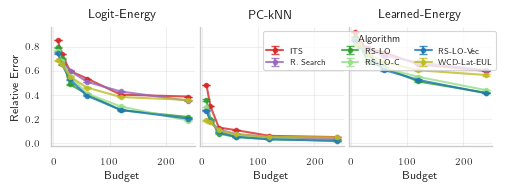

Saved: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\export\fig\comparision_search_budget\modelnet10\modelnet_default\frobenius_distance_vs_budget.pdf


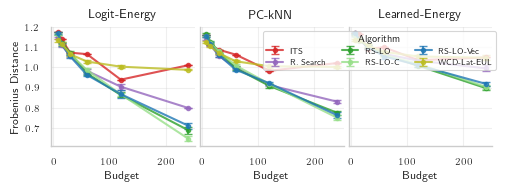

In [52]:
from collections import defaultdict


def plot_error_metrics_vs_budget(
    analysis,
    problem_names,
    metric="mean_relative_error",
    se_key="se_relative_error",
    algorithm_colors=None,
    fig_width=10,
    fig_height=None,
    figure_path=None,
    save_name="error_vs_budget"
):
    """
    Plots error metrics vs budget for each problem side-by-side.

    Parameters:
        analysis : dict
            Output from analyze_run_results_with_budget
        problem_names : list
            List of problem names to plot
        metric : str
            Metric to plot (e.g., "mean_relative_error" or "mean_frobenius")
        se_key : str
            Standard error key
        algorithm_colors : dict
            Color mapping for algorithms
        fig_width, fig_height : float
            Figure dimensions
        figure_path : str
            Directory for saving
        save_name : str
            Base filename
    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    sns.set(style="whitegrid", context="paper")

    n_problems = len(problem_names)
    if fig_height is None:
        fig_height = fig_width * 0.4

    fig, axes = plt.subplots(1, n_problems, figsize=(fig_width, fig_height), sharey=True)

    if n_problems == 1:
        axes = [axes]

    for ax, problem in zip(axes, problem_names):
        pdata = analysis[problem]
        budgets_data = pdata["budgets"]

        # Organize data by algorithm
        algo_data = defaultdict(lambda: {"budgets": [], "values": [], "errors": []})

        for budget in sorted(budgets_data.keys()):
            for algo, stats in budgets_data[budget].items():
                if stats[metric] is not None:
                    algo_data[algo]["budgets"].append(budget)
                    algo_data[algo]["values"].append(stats[metric])
                    algo_data[algo]["errors"].append(stats[se_key] if stats[se_key] is not None else 0)

        # Plot each algorithm
        for algo in sorted(algo_data.keys()):
            data = algo_data[algo]
            color = algorithm_colors.get(algo) if algorithm_colors else None

            ax.errorbar(
                data["budgets"],
                data["values"],
                yerr=np.array(data["errors"])*1.96,
                marker="o",
                label=algo,
                capsize=3,
                linewidth=1.5,
                markersize=3,
                color=color,
                alpha=0.8
            )

        ax.set_title(problem, fontsize=9)
        ax.set_xlabel("Budget", fontsize=8)
        if ax == axes[0]:
            ylabel = "Relative Error" if "relative" in metric else "Frobenius Distance"
            ax.set_ylabel(ylabel, fontsize=8)
        ax.tick_params(axis='both', labelsize=7)
        ax.grid(True, alpha=0.3)
        sns.despine(ax=ax)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels, title="Algorithm",
        loc="right", ncol=len(labels)//2,
        bbox_to_anchor=(1.0, 0.7),
        fontsize=6, title_fontsize=7
    )

    plt.tight_layout(pad=0.6, w_pad=0.3)
    plt.subplots_adjust(top=0.82)

    if figure_path is not None:
        os.makedirs(figure_path, exist_ok=True)
        pdf_path = os.path.join(figure_path, f"{save_name}.pdf")
        pgf_path = os.path.join(figure_path, f"{save_name}.pgf")
        plt.savefig(pdf_path, bbox_inches="tight")
        plt.savefig(pgf_path, bbox_inches="tight")
        print(f"Saved: {pdf_path}")

    plt.show()


# Plot relative error
plot_error_metrics_vs_budget(
    analysis=analysis,
    problem_names=problem_names_renamed,
    metric="mean_relative_error",
    se_key="se_relative_error",
    algorithm_colors=algorithm_colors,
    fig_width=W,
    figure_path=figure_path,
    save_name="relative_error_vs_budget"
)

# Plot Frobenius distance
plot_error_metrics_vs_budget(
    analysis=analysis,
    problem_names=problem_names_renamed,
    metric="mean_frobenius",
    se_key="se_frobenius",
    algorithm_colors=algorithm_colors,
    fig_width=W,
    figure_path=figure_path,
    save_name="frobenius_distance_vs_budget"
)

Saved: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\export\fig\comparision_search_budget\modelnet10\modelnet_default\relative_error_vs_budget_overall.pdf


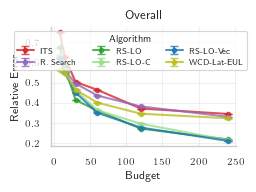

Saved: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\export\fig\comparision_search_budget\modelnet10\modelnet_default\frobenius_distance_vs_budget_overall.pdf


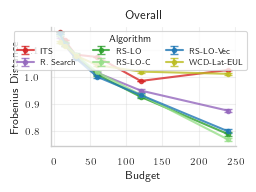

In [53]:
def compute_overall_error_metrics(analysis):
    """
    Compute overall metrics across problems with proper SE propagation.
    """
    from collections import defaultdict

    # Organize by budget and algorithm
    data_by_budget_algo = defaultdict(lambda: defaultdict(list))

    for problem, pdata in analysis.items():
        for budget, algo_stats in pdata["budgets"].items():
            for algo, stats in algo_stats.items():
                data_by_budget_algo[budget][algo].append(stats)

    # Compute means and combined SEs
    overall = defaultdict(lambda: defaultdict(dict))

    for budget, algo_dict in data_by_budget_algo.items():
        for algo, stats_list in algo_dict.items():
            N = len(stats_list)  # number of problems

            for metric_key in ["mean_relative_error", "mean_frobenius"]:
                se_key = metric_key.replace("mean_", "se_")
                std_key = metric_key.replace("mean_", "std_")

                values = [s[metric_key] for s in stats_list if s[metric_key] is not None]
                stds = [s[std_key] for s in stats_list if s[std_key] is not None]
                num_runs = [s["num_runs"] for s in stats_list]

                if not values:
                    continue

                mean_val = np.mean(values)

                # Propagate uncertainty across problems
                var_each = np.array(stds) ** 2 / np.array(num_runs)
                se_combined = np.sqrt(np.sum(var_each)) / N

                overall[budget][algo][metric_key] = mean_val
                overall[budget][algo][se_key] = se_combined

    return dict(overall)


# Compute and plot overall metrics
overall_metrics = compute_overall_error_metrics(analysis)

# Convert to analysis format for plotting
overall_analysis = {
    "Overall": {
        "budgets": overall_metrics,
        "num_datapoints": analysis[list(analysis.keys())[0]]["num_datapoints"]
    }
}

plot_error_metrics_vs_budget(
    analysis=overall_analysis,
    problem_names=["Overall"],
    metric="mean_relative_error",
    se_key="se_relative_error",
    algorithm_colors=algorithm_colors,
    fig_width=W/2,
    fig_height=W * 0.4,
    figure_path=figure_path,
    save_name="relative_error_vs_budget_overall"
)

plot_error_metrics_vs_budget(
    analysis=overall_analysis,
    problem_names=["Overall"],
    metric="mean_frobenius",
    se_key="se_frobenius",
    algorithm_colors=algorithm_colors,
    fig_width=W/2,
    fig_height=W * 0.4,
    figure_path=figure_path,
    save_name="frobenius_distance_vs_budget_overall"
)

In [54]:
def precompute_global_minmax(analysis, base_results_dir):
    """
    Precompute global min/max errors per problem across all budgets and algorithms.

    Returns:
        dict: {problem_name: {'min_errors': array, 'max_errors': array}}
    """
    import numpy as np

    PROBLEM_RENAME_REVERSE = {v: k for k, v in PROBLEM_RENAME.items()}
    ALGO_RENAME_REVERSE = {v: k for k, v in ALGO_RENAME.items()}

    global_stats = {}

    for problem in analysis.keys():
        original_problem = PROBLEM_RENAME_REVERSE.get(problem, problem)
        pdata = analysis[problem]

        all_errors_temp = []

        # Collect all errors once per problem
        for b in pdata["budgets"].keys():
            for a in pdata["budgets"][b].keys():
                a_orig = ALGO_RENAME_REVERSE.get(a, a)

                a_dir = os.path.join(base_results_dir, a_orig, f"budget_{b}")
                e_path = os.path.join(a_dir, f"eval_{original_problem}.json")

                if os.path.exists(e_path):
                    with open(e_path, "r") as f:
                        m2 = json.load(f)
                    r2 = m2.get("per_run", [m2])
                    for r in r2:
                        if "per_sample_errors" in r:
                            all_errors_temp.append(np.array(r["per_sample_errors"], dtype=float))

        if all_errors_temp:
            all_errors_temp = np.stack(all_errors_temp)
            global_stats[problem] = {
                'min_errors': np.nanmin(all_errors_temp, axis=0),
                'max_errors': np.nanmax(all_errors_temp, axis=0)
            }

    return global_stats





# Precompute global min/max once
global_minmax = precompute_global_minmax(analysis, base_results_dir)



Saved: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\export\fig\comparision_search_budget\modelnet10\modelnet_default\error_distribution_comparison_budget60.pdf


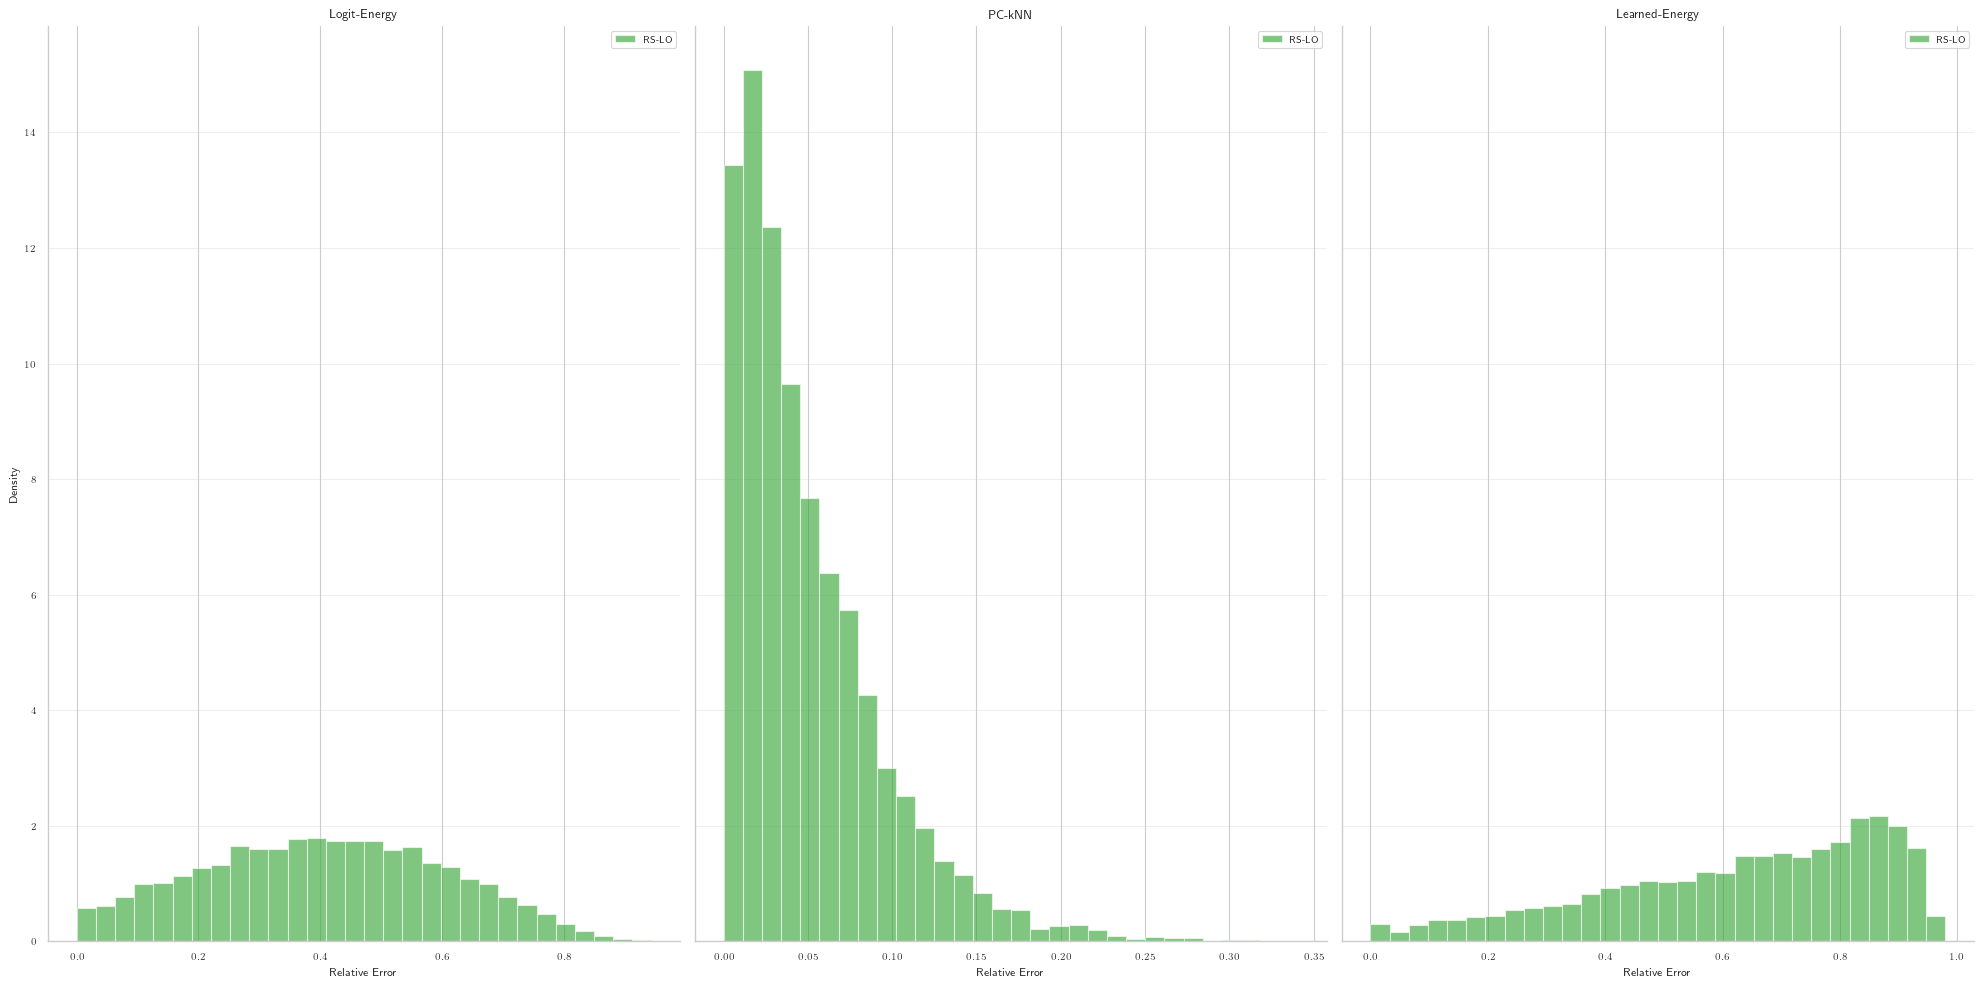

In [55]:
def plot_error_distributions(
    analysis,
    problem_names,
    algorithms,
    budget,
    global_minmax,
    metric="relative_error",
    algorithm_colors=None,
    fig_width=10,
    fig_height=None,
    figure_path=None,
    save_name="error_distributions"
):
    """
    Plots distributions of per-sample relative errors for specified algorithms at a given budget.

    Parameters:
        analysis : dict
            Output from analyze_run_results_with_budget
        problem_names : list
            List of problem names to plot (can be renamed)
        algorithms : list
            List of algorithm names to compare (can be renamed)
        budget : int
            Budget value to analyze
        global_minmax : dict
            Precomputed global min/max per problem from precompute_global_minmax()
        metric : str
            "relative_error" or "frobenius"
        algorithm_colors : dict
            Color mapping for algorithms
        fig_width, fig_height : float
            Figure dimensions
        figure_path : str
            Directory for saving
        save_name : str
            Base filename
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    PROBLEM_RENAME_REVERSE = {v: k for k, v in PROBLEM_RENAME.items()}
    ALGO_RENAME_REVERSE = {v: k for k, v in ALGO_RENAME.items()}

    sns.set(style="whitegrid", context="paper")

    n_problems = len(problem_names)
    if fig_height is None:
        fig_height = fig_width * 0.5

    fig, axes = plt.subplots(1, n_problems, figsize=(fig_width, fig_height), sharey=True)

    if n_problems == 1:
        axes = [axes]

    for ax, problem in zip(axes, problem_names):
        original_problem = PROBLEM_RENAME_REVERSE.get(problem, problem)

        # Get precomputed min/max
        min_errs = global_minmax[problem]['min_errors']
        max_errs = global_minmax[problem]['max_errors']

        for algo in algorithms:
            original_algo = ALGO_RENAME_REVERSE.get(algo, algo)

            algo_dir = os.path.join(base_results_dir, original_algo, f"budget_{budget}")
            eval_path = os.path.join(algo_dir, f"eval_{original_problem}.json")

            if not os.path.exists(eval_path):
                continue

            with open(eval_path, "r") as f:
                metrics = json.load(f)

            runs = metrics.get("per_run", [metrics])
            all_rel_errors = []

            for run in runs:
                if "per_sample_errors" not in run:
                    continue

                errs = np.array(run["per_sample_errors"], dtype=float)

                # Use precomputed min/max
                rel_errs = (errs - min_errs) / (max_errs - min_errs + 1e-12)
                rel_errs = rel_errs[~np.isnan(rel_errs)]
                all_rel_errors.extend(rel_errs)

            if all_rel_errors:
                color = algorithm_colors.get(algo) if algorithm_colors else None
                ax.hist(all_rel_errors, bins=30, alpha=0.6, label=algo, color=color, density=True)

        ax.set_title(problem, fontsize=9)
        ax.set_xlabel("Relative Error", fontsize=8)
        if ax == axes[0]:
            ax.set_ylabel("Density", fontsize=8)
        ax.tick_params(axis='both', labelsize=7)
        ax.grid(True, alpha=0.3, axis='y')
        ax.legend(fontsize=7)
        sns.despine(ax=ax)

    plt.tight_layout()

    if figure_path is not None:
        os.makedirs(figure_path, exist_ok=True)
        pdf_path = os.path.join(figure_path, f"{save_name}_budget{budget}.pdf")
        pgf_path = os.path.join(figure_path, f"{save_name}_budget{budget}.pgf")
        plt.savefig(pdf_path, bbox_inches="tight")
        plt.savefig(pgf_path, bbox_inches="tight")
        print(f"Saved: {pdf_path}")

    plt.show()

# Plot error distributions - much faster now
plot_error_distributions(
    analysis=analysis,
    problem_names=problem_names_renamed,
    algorithms=["WCD-Lat", "RS-LO"],
    budget=60,
    global_minmax=global_minmax,
    algorithm_colors=algorithm_colors,
    fig_width=W*4,
    figure_path=figure_path,
    save_name="error_distribution_comparison"
)

Run Debug: RS-LO Logit-Energy Correct: 231 Incorrect: 677
Run Debug: RS-LO Logit-Energy Correct: 224 Incorrect: 684
Run Debug: RS-LO Logit-Energy Correct: 221 Incorrect: 687
Run Debug: RS-LO Logit-Energy Correct: 230 Incorrect: 678
Run Debug: RS-LO Logit-Energy Correct: 216 Incorrect: 692
Run Debug: RS-LO PC-kNN Correct: 493 Incorrect: 415
Run Debug: RS-LO PC-kNN Correct: 499 Incorrect: 409
Run Debug: RS-LO PC-kNN Correct: 480 Incorrect: 428
Run Debug: RS-LO PC-kNN Correct: 472 Incorrect: 436
Run Debug: RS-LO PC-kNN Correct: 470 Incorrect: 438
Run Debug: RS-LO Learned-Energy Correct: 543 Incorrect: 365
Run Debug: RS-LO Learned-Energy Correct: 559 Incorrect: 349
Run Debug: RS-LO Learned-Energy Correct: 552 Incorrect: 356
Run Debug: RS-LO Learned-Energy Correct: 542 Incorrect: 366
Run Debug: RS-LO Learned-Energy Correct: 561 Incorrect: 347
Saved: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\export\fig\comparision_search_budget\modelnet10\modelnet_default\error_d

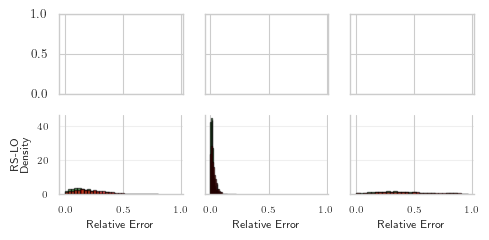

In [56]:
def plot_error_distributions_by_correctness(
    analysis,
    problem_names,
    algorithms,
    budget,
    global_minmax,
    algorithm_colors=None,
    fig_width=10,
    fig_height=None,
    figure_path=None,
    save_name="error_distributions_by_correctness"
):
    """
    Plots distributions of per-sample relative errors split by correct/incorrect predictions from each run.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import os
    import json

    PROBLEM_RENAME_REVERSE = {v: k for k, v in PROBLEM_RENAME.items()}
    ALGO_RENAME_REVERSE = {v: k for k, v in ALGO_RENAME.items()}

    sns.set(style="whitegrid", context="paper")

    n_problems = len(problem_names)
    n_algos = len(algorithms)

    if fig_height is None:
        fig_height = fig_width * 0.6 * n_algos

    fig, axes = plt.subplots(
        n_algos, n_problems,
        figsize=(fig_width, fig_height),
        sharex=True,
        sharey='row'
    )

    if n_problems == 1:
        axes = axes.reshape(-1, 1)
    if n_algos == 1:
        axes = axes.reshape(1, -1)

    for col_idx, problem in enumerate(problem_names):
        original_problem = PROBLEM_RENAME_REVERSE.get(problem, problem)
        pdata = analysis[problem]

        true_labels = pdata.get("true_labels")
        if true_labels is None:
            print(f"Warning: No label data for {problem}, skipping")
            continue

        true_labels = np.array(true_labels)
        min_errs = global_minmax[problem]['min_errors']
        max_errs = global_minmax[problem]['max_errors']

        for row_idx, algo in enumerate(algorithms):
            ax = axes[row_idx, col_idx]
            original_algo = ALGO_RENAME_REVERSE.get(algo, algo)

            algo_dir = os.path.join(base_results_dir, original_algo, f"budget_{budget}")
            eval_path = os.path.join(algo_dir, f"eval_{original_problem}.json")

            if not os.path.exists(eval_path):
                continue

            with open(eval_path, "r") as f:
                metrics = json.load(f)

            runs = metrics.get("per_run", [metrics])
            correct_rel_errors = []
            incorrect_rel_errors = []

            for run in runs:
                if "per_sample_errors" not in run or "per_sample_pred_labels" not in run:
                    continue

                errs = np.array(run["per_sample_errors"], dtype=float)
                pred_labels = np.array(run["per_sample_pred_labels"])

                # Compute correctness mask for THIS run
                n_samples = min(len(errs), len(pred_labels), len(true_labels))
                correct_mask = (true_labels[:n_samples] == pred_labels[:n_samples])

                # Compute relative errors
                rel_errs = (errs[:n_samples] - min_errs[:n_samples]) / (max_errs[:n_samples] - min_errs[:n_samples] + 1e-12)
                rel_errs = rel_errs[~np.isnan(rel_errs)]

                # Split by correctness
                correct_rel_errors.extend(rel_errs[correct_mask])
                incorrect_rel_errors.extend(rel_errs[~correct_mask])

                print("Run Debug:", algo, problem, "Correct:", np.sum(correct_mask), "Incorrect:", np.sum(~correct_mask))

            # Distinct colors for correct/incorrect
            correct_color = "green"
            incorrect_color =  "red"

            # Scale by number of samples for proper density
            total_count = len(correct_rel_errors) + len(incorrect_rel_errors)
            if total_count > 0:
                correct_weights = np.ones_like(correct_rel_errors) #/ total_count
                incorrect_weights = np.ones_like(incorrect_rel_errors) #/ total_count

                if len(correct_rel_errors) > 0:
                    ax.hist(
                        correct_rel_errors, bins=30, alpha=0.6, label="Correct",
                        color=correct_color, weights=correct_weights, edgecolor='black', linewidth=1,density=True
                    )

                if len(incorrect_rel_errors) > 0:
                    ax.hist(
                        incorrect_rel_errors, bins=30, alpha=0.6, label="Incorrect",
                        color=incorrect_color, weights=incorrect_weights, edgecolor='black', linewidth=1,density=True
                    )

            if row_idx == 0:
                ax.set_title(problem, fontsize=9)
            if col_idx == 0:
                ax.set_ylabel(f"{algo}\nDensity", fontsize=8)
            if row_idx == n_algos - 1:
                ax.set_xlabel("Relative Error", fontsize=8)

            ax.tick_params(axis='both', labelsize=7)
            ax.grid(True, alpha=0.3, axis='y')

            if row_idx == 0 and col_idx == 0:
                ax.legend(fontsize=7)

            sns.despine(ax=ax)

    plt.tight_layout()

    if figure_path is not None:
        os.makedirs(figure_path, exist_ok=True)
        pdf_path = os.path.join(figure_path, f"{save_name}_budget{budget}.pdf")
        pgf_path = os.path.join(figure_path, f"{save_name}_budget{budget}.pgf")
        plt.savefig(pdf_path, bbox_inches="tight")
        plt.savefig(pgf_path, bbox_inches="tight")
        print(f"Saved: {pdf_path}")

    plt.show()


# Plot error distributions split by correctness
plot_error_distributions_by_correctness(
    analysis=analysis,
    problem_names=problem_names_renamed,
    algorithms=["WCD-Lat", "RS-LO"],
    budget=240,
    global_minmax=global_minmax,
    algorithm_colors=algorithm_colors,
    fig_width=W,
    fig_height=W/2,
    figure_path=figure_path,
    save_name="error_distribution_by_correctness"
)


In [57]:
def precompute_global_best_matrices(analysis, base_results_dir):
    """
    Precompute global best matrices per problem across all budgets and algorithms.

    Returns:
        dict: {problem_name: array of best matrices per sample}
    """
    import numpy as np
    import json

    PROBLEM_RENAME_REVERSE = {v: k for k, v in PROBLEM_RENAME.items()}
    ALGO_RENAME_REVERSE = {v: k for k, v in ALGO_RENAME.items()}

    global_best = {}

    for problem in analysis.keys():
        original_problem = PROBLEM_RENAME_REVERSE.get(problem, problem)
        pdata = analysis[problem]

        all_errors = []
        all_matrices = []

        # Collect all errors and matrices
        for b in pdata["budgets"].keys():
            for a in pdata["budgets"][b].keys():
                a_orig = ALGO_RENAME_REVERSE.get(a, a)

                a_dir = os.path.join(base_results_dir, a_orig, f"budget_{b}")
                e_path = os.path.join(a_dir, f"eval_{original_problem}.json")

                if os.path.exists(e_path):
                    with open(e_path, "r") as f:
                        metrics = json.load(f)

                    runs = metrics.get("per_run", [metrics])
                    for run in runs:
                        if "per_sample_errors" in run and "per_sample_matrices" in run:
                            all_errors.append(np.array(run["per_sample_errors"], dtype=float))
                            all_matrices.append(run["per_sample_matrices"])

        if all_errors:
            all_errors = np.stack(all_errors)
            num_samples = all_errors.shape[1]

            # Find best run per sample
            best_run_idx = np.nanargmin(
                np.where(np.isnan(all_errors), np.inf, all_errors), axis=0
            )

            # Extract best matrices
            best_mats = [all_matrices[idx][j] for j, idx in enumerate(best_run_idx)]
            global_best[problem] = np.array(best_mats, dtype=float)

    return global_best


def plot_error_distributions_by_correctness(
    analysis,
    problem_names,
    algorithms,
    budget,
    global_minmax,
    global_best_matrices=None,
    metric="relative_error",
    algorithm_colors=None,
    fig_width=10,
    fig_height=None,
    figure_path=None,
    save_name="error_distributions_by_correctness"
):
    """
    Plots distributions of per-sample errors split by correct/incorrect predictions.

    Parameters:
        metric : str
            "relative_error" or "frobenius"
        global_best_matrices : dict
            Required if metric="frobenius". Output from precompute_global_best_matrices()
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import os
    import json

    if metric == "frobenius" and global_best_matrices is None:
        raise ValueError("global_best_matrices required for metric='frobenius'")

    PROBLEM_RENAME_REVERSE = {v: k for k, v in PROBLEM_RENAME.items()}
    ALGO_RENAME_REVERSE = {v: k for k, v in ALGO_RENAME.items()}

    sns.set(style="whitegrid", context="paper")

    n_problems = len(problem_names)
    n_algos = len(algorithms)

    if fig_height is None:
        fig_height = fig_width * 0.6 * n_algos

    fig, axes = plt.subplots(
        n_algos, n_problems,
        figsize=(fig_width, fig_height),
        sharex=True,
        sharey='row'
    )

    if n_problems == 1:
        axes = axes.reshape(-1, 1)
    if n_algos == 1:
        axes = axes.reshape(1, -1)

    for col_idx, problem in enumerate(problem_names):
        original_problem = PROBLEM_RENAME_REVERSE.get(problem, problem)
        pdata = analysis[problem]

        true_labels = pdata.get("true_labels")
        if true_labels is None:
            print(f"Warning: No label data for {problem}, skipping")
            continue

        true_labels = np.array(true_labels)

        # Get normalization data based on metric
        if metric == "relative_error":
            min_errs = global_minmax[problem]['min_errors']
            max_errs = global_minmax[problem]['max_errors']
        else:  # frobenius
            best_mats = global_best_matrices[problem]

        for row_idx, algo in enumerate(algorithms):
            ax = axes[row_idx, col_idx]
            original_algo = ALGO_RENAME_REVERSE.get(algo, algo)

            algo_dir = os.path.join(base_results_dir, original_algo, f"budget_{budget}")
            eval_path = os.path.join(algo_dir, f"eval_{original_problem}.json")

            if not os.path.exists(eval_path):
                continue

            with open(eval_path, "r") as f:
                metrics = json.load(f)

            runs = metrics.get("per_run", [metrics])
            correct_errors = []
            incorrect_errors = []

            for run in runs:
                if "per_sample_pred_labels" not in run:
                    continue

                pred_labels = np.array(run["per_sample_pred_labels"])

                if metric == "relative_error":
                    if "per_sample_errors" not in run:
                        continue
                    errs = np.array(run["per_sample_errors"], dtype=float)

                    # Compute correctness mask
                    n_samples = min(len(errs), len(pred_labels), len(true_labels))
                    correct_mask = (true_labels[:n_samples] == pred_labels[:n_samples])

                    # Compute relative errors
                    rel_errs = (errs[:n_samples] - min_errs[:n_samples]) / (
                        max_errs[:n_samples] - min_errs[:n_samples] + 1e-12
                    )
                    rel_errs = rel_errs[~np.isnan(rel_errs)]

                    # Split by correctness
                    correct_errors.extend(rel_errs[correct_mask])
                    incorrect_errors.extend(rel_errs[~correct_mask])

                else:  # frobenius
                    if "per_sample_matrices" not in run:
                        continue
                    matrices = np.array(run["per_sample_matrices"], dtype=float)

                    # Compute correctness mask
                    n_samples = min(len(matrices), len(pred_labels), len(true_labels))
                    correct_mask = (true_labels[:n_samples] == pred_labels[:n_samples])

                    # Compute Frobenius distances
                    diff = matrices[:n_samples] - best_mats[:n_samples]
                    diff_flat = diff.reshape(n_samples, -1)
                    best_flat = best_mats[:n_samples].reshape(n_samples, -1)

                    diff_norms = np.linalg.norm(diff_flat, axis=1)
                    best_norms = np.linalg.norm(best_flat, axis=1)

                    frob_dist = diff_norms / (best_norms + 1e-12)
                    frob_dist = frob_dist[~np.isnan(frob_dist)]

                    # Split by correctness
                    correct_errors.extend(frob_dist[correct_mask])
                    incorrect_errors.extend(frob_dist[~correct_mask])

                print(f"Run Debug: {algo}, {problem}, Correct: {np.sum(correct_mask)}, Incorrect: {np.sum(~correct_mask)}")

            # Distinct colors
            correct_color = "green"
            incorrect_color = "red"

            total_count = len(correct_errors) + len(incorrect_errors)
            if total_count > 0:
                if len(correct_errors) > 0:
                    ax.hist(
                        correct_errors, bins=30, alpha=0.6, label="Correct",
                        color=correct_color, edgecolor='black', linewidth=1, density=True
                    )

                if len(incorrect_errors) > 0:
                    ax.hist(
                        incorrect_errors, bins=30, alpha=0.6, label="Incorrect",
                        color=incorrect_color, edgecolor='black', linewidth=1, density=True
                    )

            if row_idx == 0:
                ax.set_title(problem, fontsize=9)
            if col_idx == 0:
                ax.set_ylabel(f"{algo}\nDensity", fontsize=8)
            if row_idx == n_algos - 1:
                xlabel = "Relative Error" if metric == "relative_error" else "Frobenius Distance"
                ax.set_xlabel(xlabel, fontsize=8)

            ax.tick_params(axis='both', labelsize=7)
            ax.grid(True, alpha=0.3, axis='y')

            if row_idx == 0 and col_idx == 0:
                ax.legend(fontsize=7)

            sns.despine(ax=ax)

    plt.tight_layout()

    if figure_path is not None:
        os.makedirs(figure_path, exist_ok=True)
        pdf_path = os.path.join(figure_path, f"{save_name}_budget{budget}.pdf")
        pgf_path = os.path.join(figure_path, f"{save_name}_budget{budget}.pgf")
        plt.savefig(pdf_path, bbox_inches="tight")
        plt.savefig(pgf_path, bbox_inches="tight")
        print(f"Saved: {pdf_path}")

    plt.show()


# Precompute global best matrices for Frobenius metric
global_best_mats = precompute_global_best_matrices(analysis, base_results_dir)



Run Debug: RS-LO, Logit-Energy, Correct: 231, Incorrect: 677
Run Debug: RS-LO, Logit-Energy, Correct: 224, Incorrect: 684
Run Debug: RS-LO, Logit-Energy, Correct: 221, Incorrect: 687
Run Debug: RS-LO, Logit-Energy, Correct: 230, Incorrect: 678
Run Debug: RS-LO, Logit-Energy, Correct: 216, Incorrect: 692
Run Debug: RS-LO, PC-kNN, Correct: 493, Incorrect: 415
Run Debug: RS-LO, PC-kNN, Correct: 499, Incorrect: 409
Run Debug: RS-LO, PC-kNN, Correct: 480, Incorrect: 428
Run Debug: RS-LO, PC-kNN, Correct: 472, Incorrect: 436
Run Debug: RS-LO, PC-kNN, Correct: 470, Incorrect: 438
Run Debug: RS-LO, Learned-Energy, Correct: 543, Incorrect: 365
Run Debug: RS-LO, Learned-Energy, Correct: 559, Incorrect: 349
Run Debug: RS-LO, Learned-Energy, Correct: 552, Incorrect: 356
Run Debug: RS-LO, Learned-Energy, Correct: 542, Incorrect: 366
Run Debug: RS-LO, Learned-Energy, Correct: 561, Incorrect: 347
Saved: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\export\fig\comparision_sear

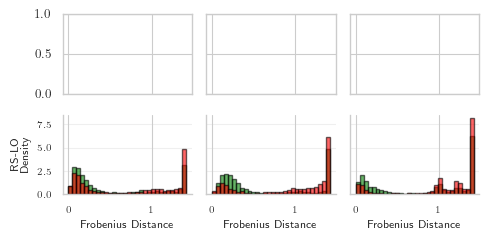

In [58]:

# Plot with Frobenius distance
plot_error_distributions_by_correctness(
    analysis=analysis,
    problem_names=problem_names_renamed,
    algorithms=["WCD-Lat", "RS-LO"],
    budget=240,
    global_minmax=global_minmax,
    global_best_matrices=global_best_mats,
    metric="frobenius",
    algorithm_colors=algorithm_colors,
    fig_width=W,
    fig_height=W/2,
    figure_path=figure_path,
    save_name="frobenius_distribution_by_correctness"
)